# 08 Cell-Type Counts and Significance

## Overview

This notebook owns compositional analysis across annotation levels using the canonical all-cells mouse object.

## Purpose

- Build sample-level cell-count matrices (wide and long formats)
- Run statistical testing across conditions with multiple-testing correction
- Export hierarchy mapping and branch-ready subtype summaries
- Define reusable plotting functions for class/subclass/supertype/cluster
- Produce the default class-level overview plot only

## Upstream Dependencies

- `adatas/brain_allcells_allgenes.h5ad`
- Required metadata: `sample`, `group`, `class`, `subclass`, `supertype`, `cluster`

## Primary Outputs

- `Results/Celltype_counts/*_wide.csv` and `*_long.csv`
- Significance tables with Welch t-test and BH-FDR correction
- Hierarchy mapping export for downstream interpretation
- Default class-level summary plot

## Standards

- Canonical group labels enforced (`Naive`, `Infected`)
- Legacy aliases (`Mock`, `OG`) normalized during processing
- Analysis ownership restricted to counts/composition (no DGE/GSEA)
- Only class-level plotting runs by default; deeper plots remain optional

# Table of Contents

1. [Overview](#overview)
2. [Purpose](#purpose)
3. [Upstream Dependencies](#upstream-dependencies)
4. [Primary Outputs](#primary-outputs)
5. [Standards](#standards)
6. [Overview Plots](#overview-plots)
7. [Hierarchy Export](#hierarchy-export)
8. [Focused Subtype Plotting](#focused-subtype-plotting)
9. [Analysis](#analysis)

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Final, cast

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


@dataclass(frozen=True)
class Notebook08Config:
    """Centralized filesystem configuration for cell-type count analysis."""

    analysis_root: Path
    results_root: Path
    count_output_dir: Path


ANALYSIS_ROOT: Final[Path] = Path("/media/drive_c/Project_Brain_snRNAseq/Analysis")

CONFIG = Notebook08Config(
    analysis_root=ANALYSIS_ROOT,
    results_root=ANALYSIS_ROOT / "Results",
    count_output_dir=ANALYSIS_ROOT / "Results" / "plots",
)
CONFIG.count_output_dir.mkdir(parents=True, exist_ok=True)

REQUIRED_OBS: Final[list[str]] = ["sample", "group", "class", "subclass", "supertype", "cluster"]
GROUP_ALIAS_MAP: Final[dict[str, str]] = {"OG": "Infected", "Mock": "Naive"}


def resolve_input_candidates() -> list[Path]:
    """Return candidate AnnData paths in priority order."""
    return [
        ANALYSIS_ROOT / "adatas" / "adata_scar_nb01_annotated_hvg.h5ad",
        ANALYSIS_ROOT / "adatas" / "brain_allcells_allgenes.h5ad",
    ]


def standardize_obs_columns(adata_obj: ad.AnnData) -> ad.AnnData:
    """Normalize common alternate obs column names to notebook-standard names."""
    rename_map = {
        "Sample": "sample",
        "Condition": "group",
        "class_name": "class",
        "subclass_name": "subclass",
        "supertype_name": "supertype",
        "cluster_name": "cluster",
    }
    present_map = {src: dst for src, dst in rename_map.items() if src in adata_obj.obs.columns and dst not in adata_obj.obs.columns}
    if present_map:
        adata_obj.obs = adata_obj.obs.rename(columns=present_map)
    return adata_obj


def load_adata_with_required_obs(candidates: list[Path], required_obs: list[str]) -> tuple[Path, ad.AnnData]:
    """Load the first candidate that can satisfy required obs columns after normalization."""
    tried: list[str] = []
    for candidate in candidates:
        if not candidate.exists():
            tried.append(f"{candidate} (missing file)")
            continue
        tmp = sc.read_h5ad(candidate)
        tmp = standardize_obs_columns(tmp)
        missing = [col for col in required_obs if col not in tmp.obs.columns]
        if not missing:
            return candidate, tmp
        tried.append(f"{candidate} (missing obs: {missing})")

    raise KeyError(
        "No input AnnData contains required obs columns. Checked: " + "; ".join(tried)
    )


adata_candidates = resolve_input_candidates()
adata_path, adata = load_adata_with_required_obs(adata_candidates, REQUIRED_OBS)
print(f"Loading AnnData from: {adata_path}")

annotations = ["class", "subclass", "supertype", "cluster"]
if not adata.obs_names.is_unique:
    warnings.warn(
        "obs_names are not unique; downstream joins may be ambiguous.",
        RuntimeWarning,
    )

display(adata.obs[["sample", "group", "class", "subclass", "supertype", "cluster"]].head())

Loading AnnData from: /media/drive_c/Project_Brain_snRNAseq/Analysis/adatas/adata_scar_nb01_annotated_hvg.h5ad


,sample,group,class,subclass,supertype,cluster
AAACAAGCAAGCCTAAACTTTAGG-1,Mock-1,Mock,31 OPC-Oligo,327 Oligo NN,1184 MOL NN_4,5285 MOL NN_4
AAACAAGCAAGCTAATACTTTAGG-1,Mock-1,Mock,11 CNU-HYa GABA,073 MEA-BST Sox6 Gaba,0341 MEA-BST Sox6 Gaba_5,1213 MEA-BST Sox6 Gaba_5
AAACAAGCACCTACTGACTTTAGG-1,Mock-1,Mock,07 CTX-MGE GABA,053 Sst Gaba,0220 Sst Gaba_7,0793 Sst Gaba_7
AAACAAGCACTAACTCACTTTAGG-1,Mock-1,Mock,20 MB GABA,207 SCs Dmbx1 Gaba,0852 SCs Dmbx1 Gaba_1,3727 SCs Dmbx1 Gaba_1
AAACAAGCACTAAGGCACTTTAGG-1,Mock-1,Mock,07 CTX-MGE GABA,053 Sst Gaba,0223 Sst Gaba_10,0803 Sst Gaba_10


In [2]:
annotation_levels: list[str] = ["class", "subclass", "supertype", "cluster"]
cell_count_outputs: dict[str, dict[str, Path]] = {}

sample_group_map = (
    adata.obs[["sample", "group"]]
    .drop_duplicates()
    .set_index("sample")["group"]
)

for level in annotation_levels:
    count_df = pd.crosstab(adata.obs[level], adata.obs["sample"])
    wide_outfile = CONFIG.count_output_dir / f"cell_counts_{level}_wide_nb07.csv"
    count_df.to_csv(wide_outfile)

    df_long = count_df.reset_index().melt(
        id_vars=level,
        var_name="sample",
        value_name="count",
    )
    df_long["group"] = df_long["sample"].map(sample_group_map)
    df_long = df_long.rename(columns={level: "celltype"})
    df_long = df_long[["celltype", "group", "sample", "count"]]

    long_outfile = CONFIG.count_output_dir / f"cell_counts_{level}_long_nb07.csv"
    df_long.to_csv(long_outfile, index=False)

    cell_count_outputs[level] = {
        "wide": wide_outfile,
        "long": long_outfile,
    }
    print(f"Saved: {long_outfile}")

Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_class_long_nb07.csv
Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_subclass_long_nb07.csv
Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_supertype_long_nb07.csv
Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_cluster_long_nb07.csv


In [3]:
def compute_welch_pvalue(group_1: pd.Series, group_2: pd.Series) -> float:
    """Return a stable Welch t-test p-value for two sample-level count vectors.

    This helper suppresses SciPy precision-loss warnings that occur when both
    groups are nearly identical, and returns 1.0 for degenerate or undefined
    comparisons so downstream plotting and multiple-testing correction remain
    well-behaved.

    Args:
        group_1: First group's sample-level counts.
        group_2: Second group's sample-level counts.

    Returns:
        Welch t-test p-value as a finite float.
    """
    group_1_clean = pd.Series(group_1, dtype="float64").dropna()
    group_2_clean = pd.Series(group_2, dtype="float64").dropna()

    if len(group_1_clean) < 2 or len(group_2_clean) < 2:
        return 1.0

    if (
        group_1_clean.nunique() == 1
        and group_2_clean.nunique() == 1
        and float(group_1_clean.iloc[0]) == float(group_2_clean.iloc[0])
    ):
        return 1.0

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Precision loss occurred in moment calculation due to catastrophic cancellation.*",
            category=RuntimeWarning,
        )
        test_result = cast(tuple[float, float], ttest_ind(group_1_clean, group_2_clean, equal_var=False))

    pval = float(test_result[1])
    if pval != pval:
        return 1.0
    return pval


def run_groupwise_celltype_ttests(df_long: pd.DataFrame, level_name: str) -> pd.DataFrame:
    """Run per-cell-type Welch t-tests between groups at a given annotation level.

    Tests each cell type independently using sample-level counts, applies BH/FDR
    multiple-testing correction, and annotates each result with a significance tier.

    Args:
        df_long: Long-format count table with columns 'celltype', 'group', 'count'.
        level_name: Annotation level label written into the 'annotation_level' column.

    Returns:
        DataFrame of per-cell-type test results including group means, raw p-value,
        BH-adjusted p-value, and significance tier ('*', '**', '***', or 'ns').

    Raises:
        KeyError: When df_long is missing required columns.
    """
    required_cols = {"celltype", "group", "count"}
    missing_cols = required_cols.difference(df_long.columns)
    if missing_cols:
        raise KeyError(f"df_long missing required columns: {sorted(missing_cols)}")

    results: list[dict[str, object]] = []
    for celltype in df_long["celltype"].dropna().astype(str).unique():
        sub_df = df_long[df_long["celltype"].astype(str) == celltype]
        groups = sorted(sub_df["group"].dropna().astype(str).unique().tolist())
        if len(groups) != 2:
            continue

        group_1, group_2 = groups
        g1 = sub_df[sub_df["group"].astype(str) == group_1]["count"]
        g2 = sub_df[sub_df["group"].astype(str) == group_2]["count"]
        if len(g1) < 2 or len(g2) < 2:
            continue

        pval = compute_welch_pvalue(g1, g2)
        results.append(
            {
                "annotation_level": level_name,
                "celltype": celltype,
                "group1": group_1,
                "group2": group_2,
                f"{group_1}_mean": g1.mean(),
                f"{group_2}_mean": g2.mean(),
                "pval": pval,
            }
        )

    result_df = pd.DataFrame(results)
    if result_df.empty:
        return result_df

    result_df["adj_pval"] = multipletests(result_df["pval"], method="fdr_bh")[1]
    result_df["significance"] = result_df["adj_pval"].map(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    )
    return result_df


for level in annotation_levels:
    long_path = cell_count_outputs[level]["long"]
    result_df = run_groupwise_celltype_ttests(pd.read_csv(long_path), level)
    sig_path = CONFIG.count_output_dir / f"cell_counts_{level}_sigdiff_nb07.csv"
    result_df.to_csv(sig_path, index=False)
    print(f"Saved: {sig_path}")


Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_class_sigdiff_nb07.csv
Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_subclass_sigdiff_nb07.csv
Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_supertype_sigdiff_nb07.csv
Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/cell_counts_cluster_sigdiff_nb07.csv


## Overview Plots

Plot cell-type counts at any annotation level. Choose one cell type, a list, or leave unset to show all.
Use `orientation="v"` for vertical bars, `top_n` to limit to the highest-count types when showing all.

In [4]:
def plot_celltype_counts(
    level: str,
    celltypes: str | list[str] | None = None,
    control_group: str = "Naive",
    test_group: str = "Infected",
    alpha: float = 0.05,
    show_pval: bool = False,
    orientation: str = "h",
    top_n: int | None = None,
    save_dir: str | None = None,
    save_name: str | None = None,
    save_counts_csv: bool = False,
    counts_csv_name: str | None = None,
    min_samples_per_group: int = 3,
    min_cells_per_sample: int | None = None,
) -> pd.DataFrame:
    """Plot grouped cell-type counts at a given annotation level with BH-corrected significance.

    Reads pre-computed long-format count CSVs produced by this notebook, then applies
    runtime filters for sample-level coverage before plotting and testing.

    Args:
        level: Annotation level to plot: 'class', 'subclass', 'supertype', or 'cluster'.
        celltypes: One cell type name, a list of names, or None to include all types.
        control_group: Reference group label (default 'Naive').
        test_group: Experimental group label (default 'Infected').
        alpha: Adjusted p-value threshold for significance annotation.
        show_pval: If True, annotate bars with the numeric adjusted p-value.
        orientation: 'h' for horizontal bars (default), 'v' for vertical bars.
        top_n: When celltypes is None, restrict to the top N types by total count.
        save_dir: Directory for SVG output; created automatically when provided.
        save_name: Optional output filename (with or without .svg) when save_dir is set.
        save_counts_csv: If True, save filtered plotting counts to CSV.
        counts_csv_name: Optional CSV filename (with or without .csv).
        min_samples_per_group: Minimum samples required in each group for a cell type.
        min_cells_per_sample: Optional minimum cell count threshold per sample row.

    Returns:
        Per-celltype significance DataFrame for the plotted cell types.

    Raises:
        FileNotFoundError: When the required count CSV is absent.
        ValueError: When data is empty after runtime filters.
    """
    long_path = CONFIG.count_output_dir / f"cell_counts_{level}_long_nb07.csv"

    if not long_path.exists():
        raise FileNotFoundError(f"Count CSV not found: {long_path}")

    df_plot = pd.read_csv(long_path)
    df_plot["group"] = df_plot["group"].astype(str).replace(GROUP_ALIAS_MAP)

    if isinstance(celltypes, str):
        selected: list[str] | None = [celltypes]
    elif celltypes is not None:
        selected = list(celltypes)
    else:
        selected = None

    if selected is not None:
        df_plot = df_plot[df_plot["celltype"].astype(str).isin(selected)].copy()
    elif top_n is not None:
        top_types = (
            df_plot.groupby("celltype")["count"]
            .sum()
            .nlargest(top_n)
            .index.tolist()
        )
        df_plot = df_plot[df_plot["celltype"].astype(str).isin(top_types)].copy()

    if min_cells_per_sample is not None:
        df_plot = df_plot[pd.to_numeric(df_plot["count"], errors="coerce") >= float(min_cells_per_sample)].copy()

    if df_plot.empty:
        raise ValueError(
            f"No data to plot for level={level!r}, celltypes={celltypes!r} after min_cells_per_sample filter."
        )

    # Enforce minimum sample representation in each group per cell type.
    if "sample" in df_plot.columns:
        rep_counts = (
            df_plot.assign(sample=df_plot["sample"].astype(str))
            .groupby(["celltype", "group"])["sample"]
            .nunique()
            .unstack(fill_value=0)
        )
    else:
        rep_counts = (
            df_plot.groupby(["celltype", "group"]).size()
            .unstack(fill_value=0)
        )

    eligible_types = rep_counts[
        (rep_counts.get(control_group, 0) >= min_samples_per_group)
        & (rep_counts.get(test_group, 0) >= min_samples_per_group)
    ].index.astype(str).tolist()

    df_plot = df_plot[df_plot["celltype"].astype(str).isin(eligible_types)].copy()
    if df_plot.empty:
        raise ValueError(
            f"No cell types meet minimum coverage: {min_samples_per_group} samples/group "
            f"for {control_group} and {test_group}."
        )

    ordered_types = (
        df_plot.groupby("celltype")["count"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )
    df_plot["celltype"] = pd.Categorical(
        df_plot["celltype"].astype(str), categories=ordered_types, ordered=True
    )

    # Recompute significance on the filtered rows so runtime thresholds are respected.
    sig_rows: list[dict[str, object]] = []
    for celltype in ordered_types:
        control_vals = df_plot.loc[
            (df_plot["celltype"].astype(str) == celltype)
            & (df_plot["group"].astype(str) == control_group),
            "count",
        ]
        test_vals = df_plot.loc[
            (df_plot["celltype"].astype(str) == celltype)
            & (df_plot["group"].astype(str) == test_group),
            "count",
        ]
        pval = compute_welch_pvalue(control_vals, test_vals)
        sig_rows.append({"celltype": str(celltype), "pval": pval})

    sig_df = pd.DataFrame(sig_rows)
    sig_df["adj_pval"] = np.nan
    valid = sig_df["pval"].notna()
    if valid.any():
        sig_df.loc[valid, "adj_pval"] = multipletests(sig_df.loc[valid, "pval"], method="fdr_bh")[1]
    sig_df["significant"] = sig_df["adj_pval"] < alpha

    bar_palette = {control_group: "lightblue", test_group: "lightcoral"}
    point_palette = {control_group: "k", test_group: "k"}
    sns.set_theme(style="whitegrid")
    n_types = len(ordered_types)

    if orientation == "h":
        _, ax = plt.subplots(figsize=(10, max(5, 0.7 * n_types)))
        sns.barplot(
            data=df_plot, y="celltype", x="count", hue="group",
            errorbar="se", capsize=0.1, palette=bar_palette, ax=ax,
        )
        sns.stripplot(
            data=df_plot, y="celltype", x="count", hue="group",
            dodge=True, palette=point_palette, size=6, ax=ax, legend=False,
        )
    else:
        _, ax = plt.subplots(figsize=(max(6, 0.9 * n_types), 8))
        sns.barplot(
            data=df_plot, x="celltype", y="count", hue="group",
            errorbar="se", capsize=0.1, palette=bar_palette, ax=ax,
        )
        sns.stripplot(
            data=df_plot, x="celltype", y="count", hue="group",
            dodge=True, palette=point_palette, size=6, ax=ax, legend=False,
        )
        plt.xticks(rotation=45, ha="right")

    for i, celltype in enumerate(ordered_types):
        row = sig_df[sig_df["celltype"].astype(str) == str(celltype)]
        if row.empty:
            continue
        adj_p = float(row["adj_pval"].iloc[0]) if pd.notna(row["adj_pval"].iloc[0]) else np.nan
        if not np.isfinite(adj_p) or adj_p >= alpha:
            continue
        star = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*"
        ct_max = max(
            float(df_plot[df_plot["celltype"].astype(str) == str(celltype)]["count"].max()), 1.0
        )
        if orientation == "h":
            y1, y2 = i - 0.2, i + 0.2
            x = ct_max * 1.05
            x_off = max(0.02 * ct_max, 0.5)
            ax.plot([x, x + x_off, x + x_off, x], [y1, y1, y2, y2], lw=1.5, color="k")
            ax.text(x + 2 * x_off, (y1 + y2) / 2, star, ha="left", va="center", fontsize=13)
            if show_pval:
                ax.text(
                    x + 3.5 * x_off, (y1 + y2) / 2,
                    f"{adj_p:.2g}", ha="left", va="center", fontsize=9,
                )
        else:
            x1, x2 = i - 0.2, i + 0.2
            y = ct_max * 1.05
            y_off = 0.03 * ct_max
            ax.plot([x1, x1, x2, x2], [y, y + y_off, y + y_off, y], lw=1.5, color="k")
            ax.text((x1 + x2) / 2, y + y_off, star, ha="center", va="bottom", fontsize=13)
            if show_pval:
                ax.text(
                    (x1 + x2) / 2, y + 2 * y_off,
                    f"{adj_p:.2g}", ha="center", va="bottom", fontsize=9,
                )

    if celltypes is None:
        title_label = "all"
    elif isinstance(celltypes, str):
        title_label = celltypes
    else:
        title_label = ", ".join(str(ct) for ct in celltypes[:3])

    if selected is None:
        tag = "all"
    else:
        tag = "_".join(s.replace(" ", "_") for s in selected[:3])

    filter_bits = [f"min samples/group = {min_samples_per_group}"]
    if min_cells_per_sample is not None:
        filter_bits.append(f"min cells/sample = {min_cells_per_sample}")
    ax.set_title(f"Cell counts - {level} ({title_label})\n" + ", ".join(filter_bits))
    plt.tight_layout()

    if save_dir:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        if save_name is None:
            out_name = f"celltype_counts_{level}_{tag}_nb07.svg"
        else:
            out_name = save_name if save_name.endswith(".svg") else f"{save_name}.svg"
        out_path = save_path / out_name
        plt.savefig(out_path)
        print(f"Saved: {out_path}")

    if save_counts_csv:
        csv_path_base = Path(save_dir) if save_dir else CONFIG.count_output_dir
        csv_path_base.mkdir(parents=True, exist_ok=True)
        if counts_csv_name is None:
            csv_name = f"celltype_counts_{level}_{tag}_nb07.csv"
        else:
            csv_name = counts_csv_name if counts_csv_name.endswith(".csv") else f"{counts_csv_name}.csv"
        counts_path = csv_path_base / csv_name
        counts_export = df_plot.copy()
        counts_export["celltype"] = counts_export["celltype"].astype(str)
        counts_export.to_csv(counts_path, index=False)
        print(f"Saved counts CSV: {counts_path}")

    plt.show()
    return sig_df[sig_df["celltype"].astype(str).isin(ordered_types)].copy()

In [5]:
def plot_grouped_subtype_counts(
    parent_level: str,
    parent_celltype: str,
    target_level: str,
    hierarchy_csv: str,
    counts_base_dir: str,
    control_group: str = "Naive",
    test_group: str = "Infected",
    correction_method: str | None = "fdr_bh",
    alpha: float = 0.05,
    pval_type: str = "p",
    orientation: str = "h",
    show_pval: bool = False,
    save_dir: str | None = None,
    save_name: str | None = None,
    save_counts_csv: bool = False,
    counts_csv_name: str | None = None,
    min_samples_per_group: int = 3,
    min_cells_per_sample: int | None = None,
) -> pd.DataFrame:
    """Plot child-level cell-type counts under a given parent with significance brackets.

    Looks up child cell types via the hierarchy mapping CSV, loads count data for
    the target annotation level, applies runtime sample/cell filters, runs Welch
    t-tests with optional FDR correction, and renders a grouped bar chart.

    Args:
        parent_level: Annotation level of the parent ('class', 'subclass', etc.).
        parent_celltype: Name of the parent cell type whose children are plotted.
        target_level: Annotation level of the child types to display.
        hierarchy_csv: Path to the celltype hierarchy mapping CSV from this notebook.
        counts_base_dir: Directory containing pre-computed long-format count CSVs.
        control_group: Reference group label.
        test_group: Experimental group label.
        correction_method: multipletests FDR method; None skips correction.
        alpha: Significance threshold for bracket annotation.
        pval_type: 'p' for raw p-values or 'adj_pval' for corrected values.
        orientation: 'h' for horizontal bars (default), 'v' for vertical bars.
        show_pval: If True, print the numeric p-value beside the significance marker.
        save_dir: Directory for SVG output; created automatically when provided.
        save_name: Optional output filename (with or without .svg) when save_dir is set.
        save_counts_csv: If True, save filtered plotting counts to CSV.
        counts_csv_name: Optional CSV filename (with or without .csv).
        min_samples_per_group: Minimum unique samples required in each group.
        min_cells_per_sample: Optional minimum cell count threshold per sample row.

    Returns:
        DataFrame with per-subtype significance test results.

    Raises:
        ValueError: When no child subtypes are found or data is empty after filtering.
    """
    hierarchy = pd.read_csv(hierarchy_csv)
    target_subtypes = (
        hierarchy.loc[hierarchy[parent_level] == parent_celltype, target_level]
        .dropna()
        .astype(str)
        .unique()
    )
    if len(target_subtypes) == 0:
        raise ValueError(
            f"No target subtypes found for {parent_level}={parent_celltype} and target={target_level}"
        )

    counts_path = Path(counts_base_dir) / f"cell_counts_{target_level}_long_nb07.csv"
    df_plot = pd.read_csv(counts_path)
    df_plot["group"] = df_plot["group"].astype(str).replace(GROUP_ALIAS_MAP)
    df_plot = df_plot[df_plot["celltype"].astype(str).isin(target_subtypes)].copy()

    if min_cells_per_sample is not None:
        df_plot = df_plot[pd.to_numeric(df_plot["count"], errors="coerce") >= float(min_cells_per_sample)].copy()

    if df_plot.empty:
        raise ValueError("Filtered plotting dataframe is empty after subtype and min_cells_per_sample filtering")

    if "sample" in df_plot.columns:
        rep_counts = (
            df_plot.assign(sample=df_plot["sample"].astype(str))
            .groupby(["celltype", "group"])["sample"]
            .nunique()
            .unstack(fill_value=0)
        )
    else:
        rep_counts = (
            df_plot.groupby(["celltype", "group"]).size()
            .unstack(fill_value=0)
        )

    eligible_subtypes = rep_counts[
        (rep_counts.get(control_group, 0) >= min_samples_per_group)
        & (rep_counts.get(test_group, 0) >= min_samples_per_group)
    ].index.astype(str).tolist()

    target_subtypes = [st for st in target_subtypes if str(st) in eligible_subtypes]
    df_plot = df_plot[df_plot["celltype"].astype(str).isin(target_subtypes)].copy()

    if not target_subtypes or df_plot.empty:
        raise ValueError(
            f"No subtypes meet minimum coverage: {min_samples_per_group} samples/group "
            f"for {control_group} and {test_group}."
        )

    results: list[dict[str, object]] = []
    for subtype in target_subtypes:
        control_vals = df_plot.loc[
            (df_plot["celltype"].astype(str) == subtype)
            & (df_plot["group"].astype(str) == control_group),
            "count",
        ]
        test_vals = df_plot.loc[
            (df_plot["celltype"].astype(str) == subtype)
            & (df_plot["group"].astype(str) == test_group),
            "count",
        ]
        pval = compute_welch_pvalue(control_vals, test_vals)
        results.append({"celltype": subtype, "pval": pval})

    results_df = pd.DataFrame(results)
    if correction_method and not results_df.empty:
        valid = results_df["pval"].notna()
        results_df["adj_pval"] = np.nan
        if valid.any():
            reject, pvals_corrected, _, _ = multipletests(
                results_df.loc[valid, "pval"], method=correction_method, alpha=alpha
            )
            results_df.loc[valid, "adj_pval"] = pvals_corrected
            results_df["significant"] = False
            results_df.loc[valid, "significant"] = reject
        else:
            results_df["significant"] = False
    else:
        results_df["adj_pval"] = results_df.get("pval", pd.Series(dtype=float))
        results_df["significant"] = results_df.get("pval", pd.Series(dtype=float)) < alpha

    sig_col = "pval" if pval_type == "p" else "adj_pval"
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, max(6, 0.75 * len(target_subtypes))))
    bar_palette = {control_group: "lightblue", test_group: "lightcoral"}
    point_palette = {control_group: "k", test_group: "k"}

    if orientation == "h":
        ax = sns.barplot(
            data=df_plot, y="celltype", x="count", hue="group",
            errorbar="se", capsize=0.1, palette=bar_palette,
        )
        sns.stripplot(
            data=df_plot, y="celltype", x="count", hue="group",
            dodge=True, palette=point_palette, size=7, ax=ax, legend=False,
        )
    else:
        ax = sns.barplot(
            data=df_plot, x="celltype", y="count", hue="group",
            errorbar="se", capsize=0.1, palette=bar_palette,
        )
        sns.stripplot(
            data=df_plot, x="celltype", y="count", hue="group",
            dodge=True, palette=point_palette, size=7, ax=ax, legend=False,
        )
        plt.xticks(rotation=45, ha="right")

    for i, subtype in enumerate(target_subtypes):
        row = results_df[results_df["celltype"] == subtype]
        if row.empty:
            continue
        pval = float(row[sig_col].iloc[0]) if pd.notna(row[sig_col].iloc[0]) else np.nan
        if not np.isfinite(pval) or pval >= alpha:
            continue
        subtype_max = max(
            float(df_plot.loc[df_plot["celltype"].astype(str) == subtype, "count"].max()), 1.0
        )
        if orientation == "h":
            y1, y2 = i - 0.2, i + 0.2
            x = subtype_max * 1.05
            x_offset = max(0.02 * subtype_max, 0.2)
            ax.plot([x, x + x_offset, x + x_offset, x], [y1, y1, y2, y2], lw=1.5, color="k")
            ax.text(x + 2 * x_offset, (y1 + y2) / 2, "*", ha="left", va="center", fontsize=14)
            if show_pval:
                ax.text(
                    x + 3.2 * x_offset, (y1 + y2) / 2,
                    f"{pval:.2g}", ha="left", va="center", fontsize=10,
                )
        else:
            x1, x2 = i - 0.2, i + 0.2
            y = subtype_max * 1.05
            y_off = 0.03 * subtype_max
            ax.plot([x1, x1, x2, x2], [y, y + y_off, y + y_off, y], lw=1.5, color="k")
            ax.text((x1 + x2) / 2, y + y_off, "*", ha="center", va="bottom", fontsize=14)
            if show_pval:
                ax.text(
                    (x1 + x2) / 2, y + 2 * y_off,
                    f"{pval:.2g}", ha="center", va="bottom", fontsize=10,
                )

    filter_bits = [f"min samples/group = {min_samples_per_group}"]
    if min_cells_per_sample is not None:
        filter_bits.append(f"min cells/sample = {min_cells_per_sample}")

    plt.title(f"{parent_celltype} -> {target_level} counts\n" + ", ".join(filter_bits))
    plt.tight_layout()

    if save_dir:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        orientation_label = "horizontal" if orientation == "h" else "vertical"
        if save_name is None:
            out_name = f"{parent_celltype.replace(' ', '_')}_{target_level}_{orientation_label}.svg"
        else:
            out_name = save_name if save_name.endswith(".svg") else f"{save_name}.svg"
        full_path = save_path / out_name
        plt.savefig(full_path)
        print(f"Saved plot to: {full_path}")

    if save_counts_csv:
        csv_path_base = Path(save_dir) if save_dir else Path(counts_base_dir)
        csv_path_base.mkdir(parents=True, exist_ok=True)
        if counts_csv_name is None:
            csv_name = f"{parent_celltype.replace(' ', '_')}_{target_level}_counts_nb07.csv"
        else:
            csv_name = counts_csv_name if counts_csv_name.endswith(".csv") else f"{counts_csv_name}.csv"
        counts_path = csv_path_base / csv_name
        counts_export = df_plot.copy()
        counts_export["celltype"] = counts_export["celltype"].astype(str)
        counts_export.to_csv(counts_path, index=False)
        print(f"Saved counts CSV: {counts_path}")

    plt.show()
    return results_df

## Hierarchy Export

In [6]:
hierarchy_df = (
    adata.obs[["class", "subclass", "supertype", "cluster"]]
    .drop_duplicates()
    .sort_values(by=["class", "subclass", "supertype", "cluster"])
    .reset_index(drop=True)
)

hierarchy_csv_path = CONFIG.count_output_dir / "celltype_hierarchy_mapping_nb07.csv"
hierarchy_df.to_csv(hierarchy_csv_path, index=False)
print(f"Saved hierarchy mapping: {hierarchy_csv_path}")
display(hierarchy_df.head(10))

Saved hierarchy mapping: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/celltype_hierarchy_mapping_nb07.csv


,class,subclass,supertype,cluster
0,01 IT-ET Glut,001 CLA-EPd-CTX Car3 Glut,0001 CLA-EPd-CTX Car3 Glut_1,0001 CLA-EPd-CTX Car3 Glut_1
1,01 IT-ET Glut,001 CLA-EPd-CTX Car3 Glut,0001 CLA-EPd-CTX Car3 Glut_1,0002 CLA-EPd-CTX Car3 Glut_1
2,01 IT-ET Glut,001 CLA-EPd-CTX Car3 Glut,0001 CLA-EPd-CTX Car3 Glut_1,0003 CLA-EPd-CTX Car3 Glut_1
3,01 IT-ET Glut,001 CLA-EPd-CTX Car3 Glut,0001 CLA-EPd-CTX Car3 Glut_1,0004 CLA-EPd-CTX Car3 Glut_1
4,01 IT-ET Glut,001 CLA-EPd-CTX Car3 Glut,0002 CLA-EPd-CTX Car3 Glut_2,0005 CLA-EPd-CTX Car3 Glut_2
5,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,0006 IT EP-CLA Glut_1
6,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,0007 IT EP-CLA Glut_1
7,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,0008 IT EP-CLA Glut_1
8,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,0009 IT EP-CLA Glut_1
9,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,0011 IT EP-CLA Glut_1


# Functions

### Plotting API Reference (Primary Functions Only)

This section documents only the two plotting entry points used in analysis.

## 1) `plot_celltype_counts(...)`

```python
plot_celltype_counts(
    level: str,
    celltypes: str | list[str] | None = None,
    control_group: str = "Naive",
    test_group: str = "Infected",
    alpha: float = 0.05,
    show_pval: bool = False,
    orientation: str = "h",
    top_n: int | None = None,
    save_dir: str | None = None,
    save_name: str | None = None,
    save_counts_csv: bool = False,
    counts_csv_name: str | None = None,
    min_samples_per_group: int = 3,
    min_cells_per_sample: int | None = None,
) -> pd.DataFrame
```
### Description
This function plots counts for all cell types at a given annotation level, or a selected subset (single or list), with significance testing.

### Variable input options
- `level`:
  - Allowed: `"class"`, `"subclass"`, `"supertype"`, `"cluster"`
- `celltypes`:
  - `None`: include all cell types (or top N if `top_n` is set)
  - `str`: one cell type name
  - `list[str]`: explicit subset of cell type names
- `control_group`:
  - Any group label present in `group` column
  - Typical/default: `"Naive"`
- `test_group`:
  - Any group label present in `group` column
  - Typical/default: `"Infected"`
- `alpha`:
  - Any float in `(0, 1)`
  - Used as significance cutoff for adjusted p-values
- `show_pval`:
  - `True` or `False`
- `orientation`:
  - `"h"` (horizontal) or `"v"` (vertical)
- `top_n`:
  - `None`: no top-N reduction
  - Positive `int`: keep highest total-count cell types when `celltypes=None`
- `save_dir`:
  - `None`: do not save
  - `str`: filesystem directory to save SVG
- `save_name`:
  - `None`: use default auto-generated plot filename
  - `str`: custom plot filename; `.svg` is added if missing
- `save_counts_csv`:
  - `False` (default): do not export counts
  - `True`: export filtered plotting counts to CSV
- `counts_csv_name`:
  - `None`: use default auto-generated CSV filename
  - `str`: custom CSV filename; `.csv` is added if missing
- `min_samples_per_group`:
  - Positive `int`
  - Enforces minimum number of samples in each group per cell type
- `min_cells_per_sample`:
  - `None`: no per-sample count filter
  - Non-negative `int`: keep rows with `count >= min_cells_per_sample`

### Return
- `pd.DataFrame` with per-celltype significance columns:
  - `celltype`, `pval`, `adj_pval`, `significant`

## 2) `plot_grouped_subtype_counts(...)`

```python
plot_grouped_subtype_counts(
    parent_level: str,
    parent_celltype: str,
    target_level: str,
    hierarchy_csv: str,
    counts_base_dir: str,
    control_group: str = "Naive",
    test_group: str = "Infected",
    correction_method: str | None = "fdr_bh",
    alpha: float = 0.05,
    pval_type: str = "p",
    orientation: str = "h",
    show_pval: bool = False,
    save_dir: str | None = None,
    save_name: str | None = None,
    save_counts_csv: bool = False,
    counts_csv_name: str | None = None,
    min_samples_per_group: int = 3,
    min_cells_per_sample: int | None = None,
) -> pd.DataFrame
```
### Description
This function plots counts of child subtypes within a selected parent cell type, with significance testing.

### Variable input options
- `parent_level`:
  - Allowed: `"class"`, `"subclass"`, `"supertype"`, `"cluster"`
- `parent_celltype`:
  - `str` matching a value in `hierarchy_csv[parent_level]`
- `target_level`:
  - Allowed: `"class"`, `"subclass"`, `"supertype"`, `"cluster"`
  - Usually a finer level than `parent_level`
- `hierarchy_csv`:
  - `str` path to hierarchy mapping CSV
- `counts_base_dir`:
  - `str` directory containing `cell_counts_<target_level>_long_nb07.csv`
- `control_group`:
  - Any group label present in data (default `"Naive"`)
- `test_group`:
  - Any group label present in data (default `"Infected"`)
- `correction_method`:
  - `"fdr_bh"` (default), any valid `statsmodels.multipletests` method string, or `None` to skip correction
- `alpha`:
  - Any float in `(0, 1)`
- `pval_type`:
  - `"p"` (raw p-value) or `"adj_pval"` (multiple-testing corrected)
- `orientation`:
  - `"h"` or `"v"`
- `show_pval`:
  - `True` or `False`
- `save_dir`:
  - `None` or output directory `str`
- `save_name`:
  - `None`: use default auto-generated plot filename
  - `str`: custom plot filename; `.svg` is added if missing
- `save_counts_csv`:
  - `False` (default): do not export counts
  - `True`: export filtered plotting counts to CSV
- `counts_csv_name`:
  - `None`: use default auto-generated CSV filename
  - `str`: custom CSV filename; `.csv` is added if missing
- `min_samples_per_group`:
  - Positive `int`; minimum samples per group per subtype
- `min_cells_per_sample`:
  - `None` or non-negative `int`; row-wise `count` filter

### Return
- `pd.DataFrame` with subtype-level significance columns:
  - `celltype`, `pval`, `adj_pval`, `significant`

## Minimal examples

```python
plot_celltype_counts(
    level="class",
    min_samples_per_group=3,
    min_cells_per_sample=50,
    save_dir=str(CONFIG.count_output_dir / "plots"),
    save_name="class_counts_custom",
    save_counts_csv=True,
    counts_csv_name="class_counts_custom_filtered",
    orientation="h",
)
```

```python
plot_grouped_subtype_counts(
    parent_level="class",
    parent_celltype="05 OB-IMN GABA",
    target_level="subclass",
    hierarchy_csv=str(hierarchy_csv_path),
    counts_base_dir=str(CONFIG.count_output_dir),
    pval_type="adj_pval",
    min_samples_per_group=3,
    min_cells_per_sample=50,
    save_dir=str(CONFIG.count_output_dir / "subtype_plots"),
    save_name="ob_imn_gaba_subclass_custom",
    save_counts_csv=True,
    counts_csv_name="ob_imn_gaba_subclass_counts",
)
```

## Analysis

This section is set up for safe default execution.

- Default run: class-level overview plot only.
- Optional runs (single type, selected types, and subclass drill-down) are provided as templates below and are disabled by default.

`plot_celltype_counts(level, celltypes, ...)` builds overview plots at any annotation level.
`plot_grouped_subtype_counts(parent_level, parent_celltype, target_level, ...)` drills down from a parent to child annotations.

Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/overview_plots/celltype_counts_class_all_nb07.svg


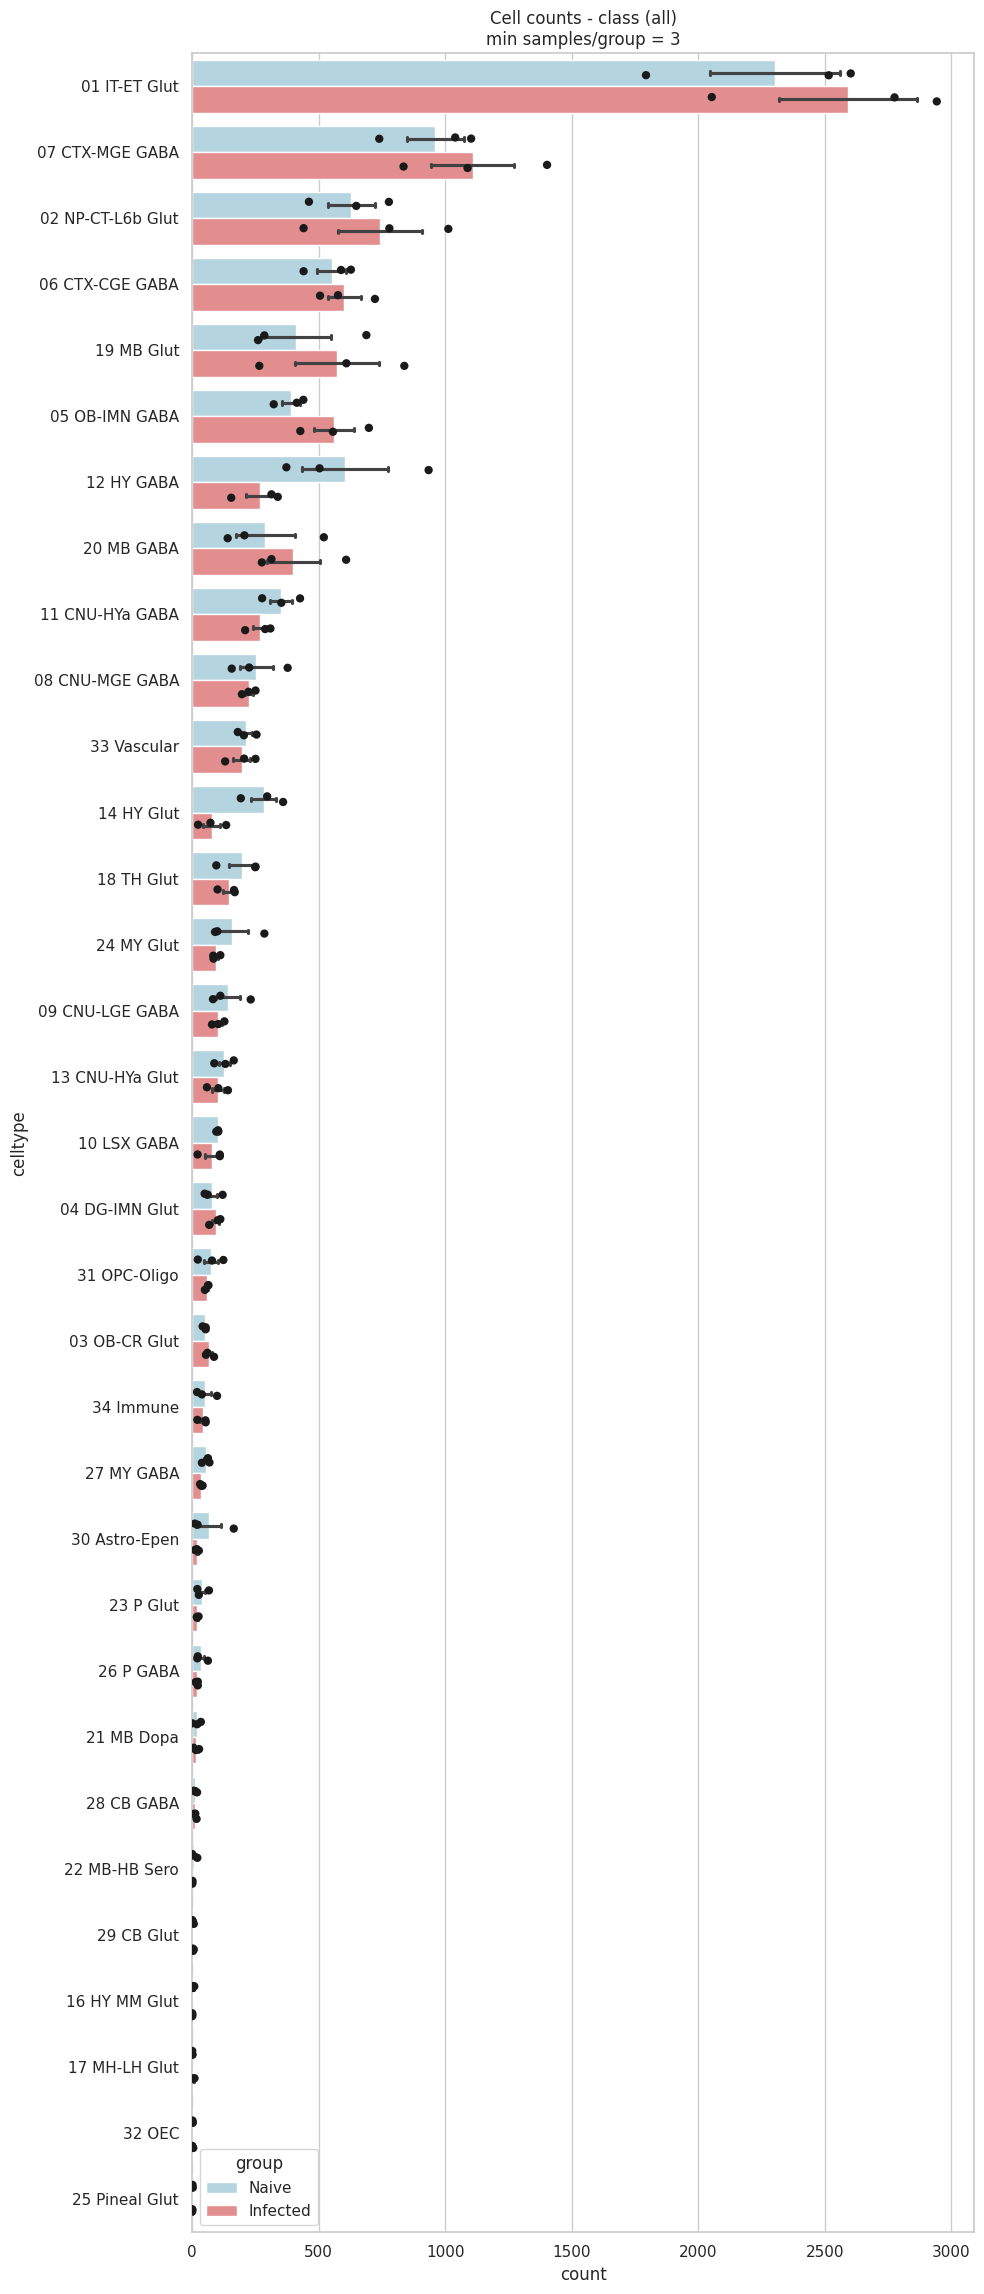

,celltype,pval,adj_pval,significant
0,01 IT-ET Glut,0.486683,0.786168,False
1,07 CTX-MGE GABA,0.501719,0.786168,False
2,02 NP-CT-L6b Glut,0.585715,0.786168,False
3,06 CTX-CGE GABA,0.595582,0.786168,False
4,19 MB Glut,0.503386,0.786168,False
5,05 OB-IMN GABA,0.150812,0.786168,False
6,12 HY GABA,0.178841,0.786168,False
7,20 MB GABA,0.523897,0.786168,False
8,11 CNU-HYa GABA,0.201376,0.786168,False
9,08 CNU-MGE GABA,0.694634,0.818676,False


In [7]:
# ── plot_celltype_counts: default overview ──────────────────────────────────
# All cell types at the class level, horizontal bars, significance brackets.
# Saves SVG to Results/Celltype_counts/overview_plots/.
plot_celltype_counts(
    level="class",
    orientation="h",
    save_dir=str(CONFIG.count_output_dir / "overview_plots"),
)

In [8]:
# Optional example 1 (disabled): single selected cell type at class level.
# Uncomment to run later.

# plot_celltype_counts(
#     level="class",
#     celltypes="05 OB-IMN GABA",
#     show_pval=True,
# )

In [9]:
# Optional example 2 (disabled): multiple selected class-level cell types.
# Uncomment to run later.

# plot_celltype_counts(
#     level="class",
#     celltypes=["05 OB-IMN GABA", "30 Astrocyte"],
#     show_pval=True,
#     orientation="h",
# )

In [10]:
# Optional example 3 (disabled): subclass drill-down from a class parent.
# Uncomment to run later.

# plot_grouped_subtype_counts(
#     parent_level="class",
#     parent_celltype="05 OB-IMN GABA",
#     target_level="subclass",
#     hierarchy_csv=str(hierarchy_csv_path),
#     counts_base_dir=str(CONFIG.count_output_dir),
#     control_group="Naive",
#     test_group="Infected",
#     orientation="h",
#     show_pval=False,
#     save_dir=str(CONFIG.count_output_dir / "subtype_plots"),
# )

Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/class_counts_cell#filtered_nb08.svg
Saved counts CSV: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/plots/class_counts_cell#filtered_nb08.csv


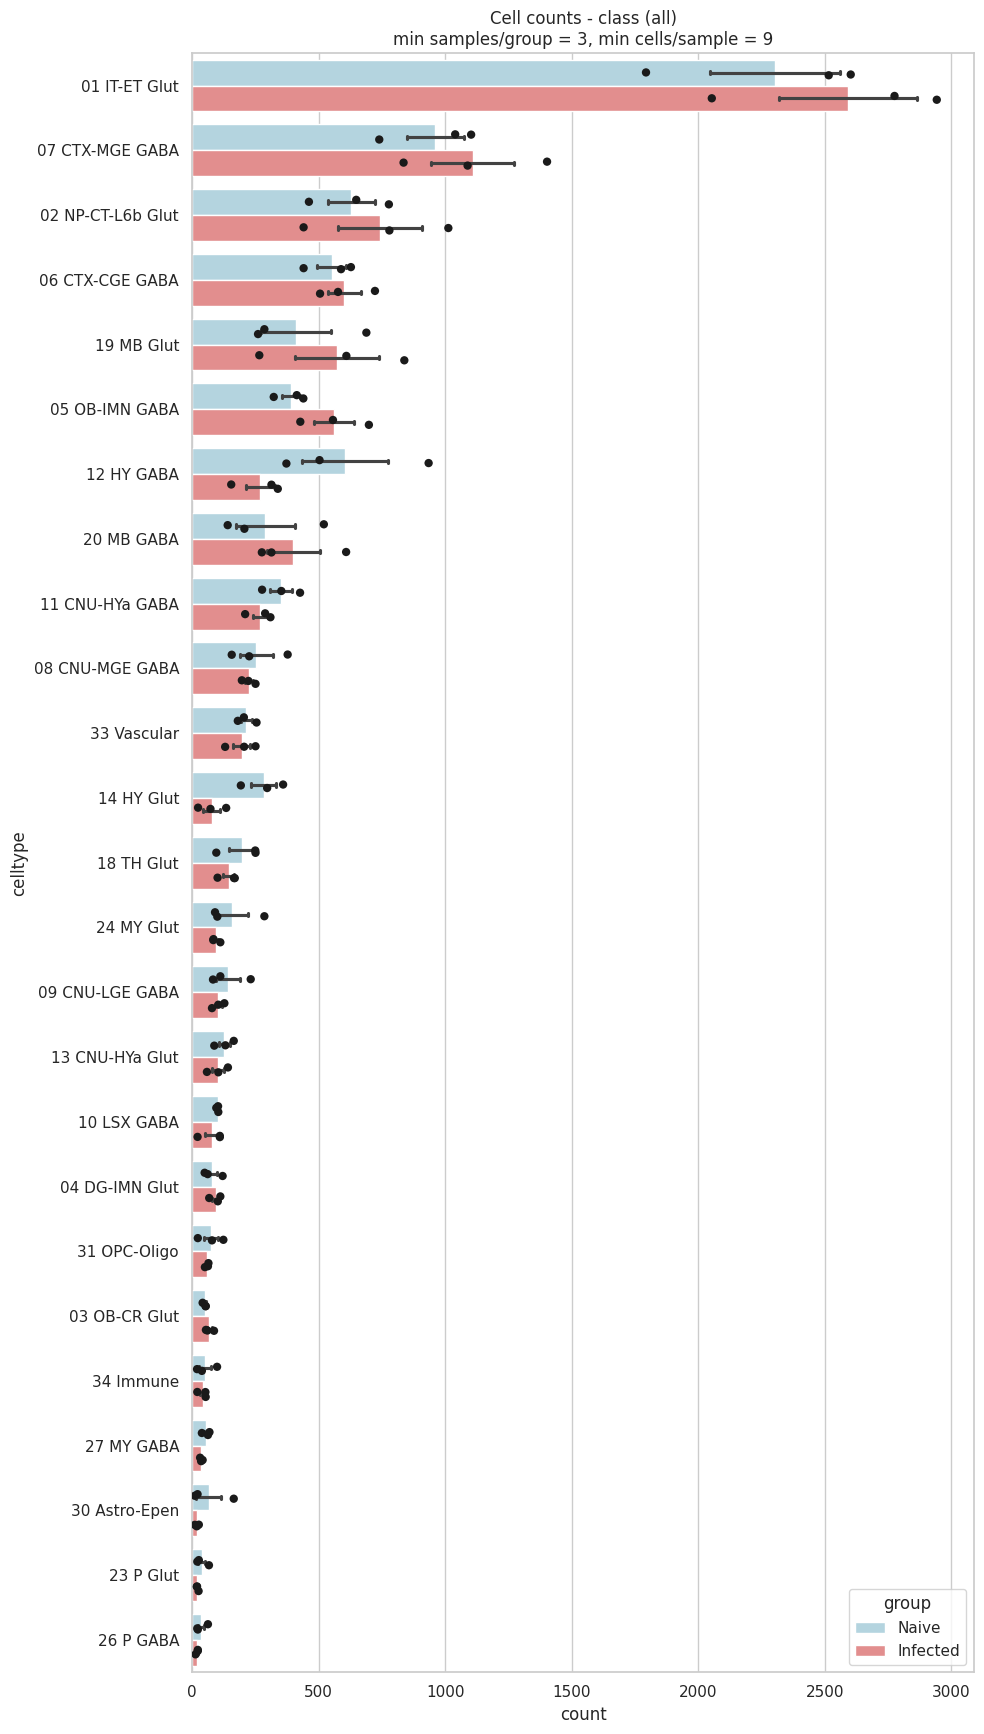

,celltype,pval,adj_pval,significant
0,01 IT-ET Glut,0.486683,0.709026,False
1,07 CTX-MGE GABA,0.501719,0.709026,False
2,02 NP-CT-L6b Glut,0.585715,0.709026,False
3,06 CTX-CGE GABA,0.595582,0.709026,False
4,19 MB Glut,0.503386,0.709026,False
5,05 OB-IMN GABA,0.150812,0.709026,False
6,12 HY GABA,0.178841,0.709026,False
7,20 MB GABA,0.523897,0.709026,False
8,11 CNU-HYa GABA,0.201376,0.709026,False
9,08 CNU-MGE GABA,0.694634,0.723577,False


In [11]:
plot_celltype_counts(
    level="class",
    min_samples_per_group=3,
    min_cells_per_sample=9,
    orientation="h",
    save_dir=str(CONFIG.count_output_dir),
    save_name="class_counts_cell#filtered_nb08.svg",
    save_counts_csv=True,
    counts_csv_name="class_counts_cell#filtered_nb08.csv",
)